<a href="https://colab.research.google.com/github/azrapatvi/dl-practice/blob/main/8_early_stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import make_circles

In [3]:
X,y=make_circles(n_samples=100,noise=0.1,random_state=42)

In [4]:
X

array([[-0.36503093, -0.76613441],
       [ 0.79142545,  0.42486577],
       [-0.62605489,  0.52993267],
       [ 0.71938348, -0.59898403],
       [ 0.87586276, -0.79693694],
       [ 0.28238185, -0.8096356 ],
       [-0.88398798,  0.19969581],
       [-0.61452907, -0.4783401 ],
       [ 0.35579647,  1.02466875],
       [ 0.92202981, -0.08438964],
       [-0.65247738,  0.67395748],
       [-0.79396809, -0.59912738],
       [-0.51151371,  0.09644282],
       [-0.61403158, -0.80193362],
       [ 0.33448411, -0.53212261],
       [ 1.03859873,  0.56412698],
       [-0.76438584, -0.01060355],
       [-0.83589873, -0.2305685 ],
       [-0.08545191,  0.97514198],
       [-0.6327045 , -0.70551635],
       [ 0.5698093 ,  0.43425039],
       [ 0.12264074, -0.82399785],
       [-0.90712258, -0.25646566],
       [ 0.4487963 , -0.89499225],
       [-0.71416997,  0.84200403],
       [-0.41864357,  1.04254495],
       [ 0.24241093, -1.00243527],
       [ 0.73117762, -0.53125463],
       [ 0.35950546,

In [5]:
X[:,0]

array([-0.36503093,  0.79142545, -0.62605489,  0.71938348,  0.87586276,
        0.28238185, -0.88398798, -0.61452907,  0.35579647,  0.92202981,
       -0.65247738, -0.79396809, -0.51151371, -0.61403158,  0.33448411,
        1.03859873, -0.76438584, -0.83589873, -0.08545191, -0.6327045 ,
        0.5698093 ,  0.12264074, -0.90712258,  0.4487963 , -0.71416997,
       -0.41864357,  0.24241093,  0.73117762,  0.35950546, -0.82842289,
        0.29605402,  0.88559988, -0.12351199, -0.89597422,  0.70644267,
        0.7327543 , -0.47281113, -0.2609427 , -0.31355726, -0.37453692,
        0.99492465, -0.34681201,  0.52774876,  0.73596476, -1.04061296,
       -0.74331485, -0.45828083, -0.88307924,  0.07079743, -0.16556161,
       -1.16316766,  1.02982505, -0.59596652,  0.14440579,  0.50727786,
       -0.65842141,  0.78565803, -0.16420415, -0.17231541,  0.01689765,
        0.71749172,  0.6977023 ,  0.76446937,  0.50556697,  0.83158909,
       -0.33761021,  0.68266906, -0.37349585,  0.11259313,  1.02

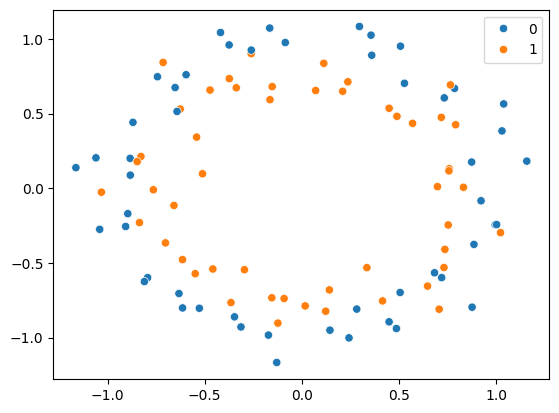

In [6]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)
plt.show()

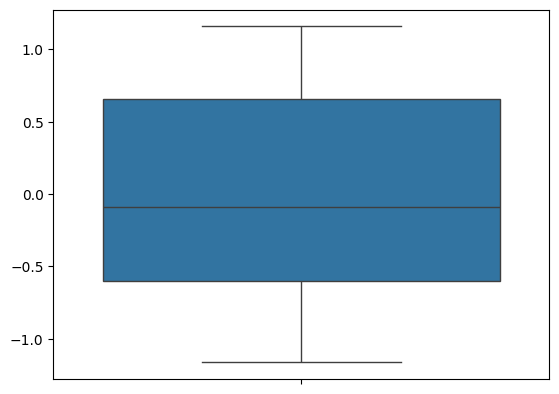

In [7]:
sns.boxplot(X[:,0])
plt.show()

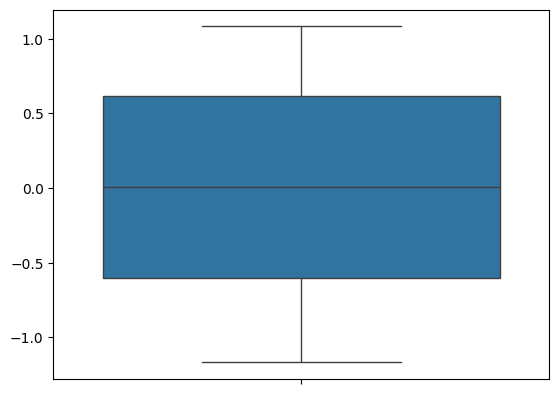

In [8]:
sns.boxplot(X[:,1])
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [10]:
y_train

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0])

In [11]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model=Sequential([
    Dense(16,activation='relu',input_dim=2),
    Dense(8,activation='relu'),
    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# as we are doing binary classification soo we will be using loss binary croos entropy
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [14]:
history=model.fit(X_train,y_train,epochs=2000,verbose=1,validation_data=(X_test,y_test))

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 526ms/step - accuracy: 0.5000 - loss: 0.6959 - val_accuracy: 0.5000 - val_loss: 0.7045
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5250 - loss: 0.6953 - val_accuracy: 0.5000 - val_loss: 0.7040
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5250 - loss: 0.6949 - val_accuracy: 0.5500 - val_loss: 0.7040
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5250 - loss: 0.6946 - val_accuracy: 0.5000 - val_loss: 0.7039
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5250 - loss: 0.6943 - val_accuracy: 0.5000 - val_loss: 0.7036
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5125 - loss: 0.6940 - val_accuracy: 0.5000 - val_loss: 0.7040
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5250 - loss: 0.6937 - val_accuracy: 0.4500 - val_loss: 0.7038
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5250 - loss: 0.6934 - val_accuracy: 0.4500 - 

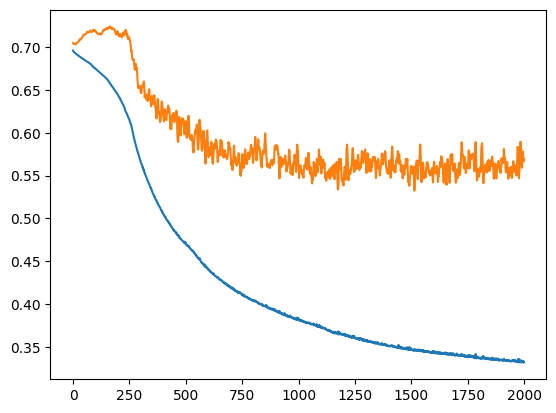

In [15]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.show()

In [16]:
#early stopping

model=Sequential([
    Dense(16,activation='relu',input_dim=2),
    Dense(8,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [17]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(
    monitor='val_loss',
    mode='min',
    min_delta=0.001,
    patience=5,
    restore_best_weights=True
)

history=model.fit(X_train,y_train,epochs=2000,verbose=1,validation_data=(X_test,y_test),callbacks=early_stop)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 475ms/step - accuracy: 0.5500 - loss: 0.6951 - val_accuracy: 0.2500 - val_loss: 0.7388
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5500 - loss: 0.6940 - val_accuracy: 0.3000 - val_loss: 0.7366
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5500 - loss: 0.6936 - val_accuracy: 0.3000 - val_loss: 0.7344
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5500 - loss: 0.6931 - val_accuracy: 0.3000 - val_loss: 0.7336
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5625 - loss: 0.6929 - val_accuracy: 0.3000 - val_loss: 0.7321
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5625 - loss: 0.6924 - val_accuracy: 0.3000 - val_loss: 0.7315
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5625 - loss: 0.6920 - val_accuracy: 0.3000 - val_loss: 0.7308
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5625 - loss: 0.6916 - val_accuracy: 0.3000 - 

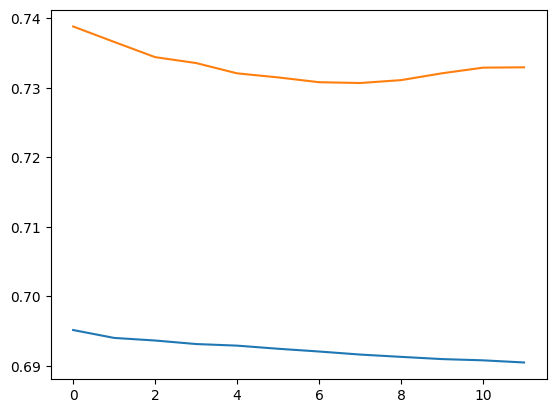

In [19]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.show()